In [24]:
from SPARQLWrapper import SPARQLWrapper, JSON
from pandas import json_normalize
from pprint import pprint
import pandas as pd

In [29]:
# see https://foundation.wikimedia.org/wiki/Policy:User-Agent_policy
user_agent = 'TripleSentenceGeneratorBot/0.0 (https://github.com/swissarthurfreeman/; arthur.freeman@unige.ch)'
sparqlwd = SPARQLWrapper("https://query.wikidata.org/sparql", agent=user_agent)

q = """
SELECT ?item ?itemLabel
WHERE
{
  ?item wdt:P31 wd:Q146. # Must be a cat
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 10
"""

sparqlwd.setQuery(q)
sparqlwd.setReturnFormat(JSON)

results = sparqlwd.query().convert()
pprint(results)

{'head': {'vars': ['item', 'itemLabel']},
 'results': {'bindings': [{'item': {'type': 'uri',
                                    'value': 'http://www.wikidata.org/entity/Q378619'},
                           'itemLabel': {'type': 'literal',
                                         'value': 'CC',
                                         'xml:lang': 'en'}},
                          {'item': {'type': 'uri',
                                    'value': 'http://www.wikidata.org/entity/Q498787'},
                           'itemLabel': {'type': 'literal',
                                         'value': 'Muezza',
                                         'xml:lang': 'en'}},
                          {'item': {'type': 'uri',
                                    'value': 'http://www.wikidata.org/entity/Q677525'},
                           'itemLabel': {'type': 'literal',
                                         'value': 'Orangey',
                                         'xml:lang': 'en'}},
 

In [27]:
print(results.keys())

dict_keys(['head', 'results'])


In [ ]:
results_df = json_normalize(results['results']['bindings'])
print(results_df)

    item.type                                item.value itemLabel.xml:lang  \
0         uri  http://www.wikidata.org/entity/Q42442324                 en   
1         uri  http://www.wikidata.org/entity/Q43260736                 en   
2         uri  http://www.wikidata.org/entity/Q48895080                 en   
3         uri  http://www.wikidata.org/entity/Q49581026                 en   
4         uri  http://www.wikidata.org/entity/Q50378472                 en   
..        ...                                       ...                ...   
211       uri  http://www.wikidata.org/entity/Q27745011                 en   
212       uri  http://www.wikidata.org/entity/Q28114532                 en   
213       uri  http://www.wikidata.org/entity/Q28665865                 en   
214       uri  http://www.wikidata.org/entity/Q28792126                 en   
215       uri  http://www.wikidata.org/entity/Q30600575                 en   

    itemLabel.type itemLabel.value  
0          literal     Kii

In [20]:
results_df.columns

Index(['item.type', 'item.value', 'itemLabel.xml:lang', 'itemLabel.type',
       'itemLabel.value'],
      dtype='object')

What we can try to do is retrieve all films for example, then retrieve their publication date, screenwriters, directors, genre, awards, cast members, 
e.g. all relations we have from the ontology if they're present, checkout https://www.wikidata.org/wiki/Q108839994.

Once we have a list of triples per film, we can generate ask gpt to generate a paragraph from it.

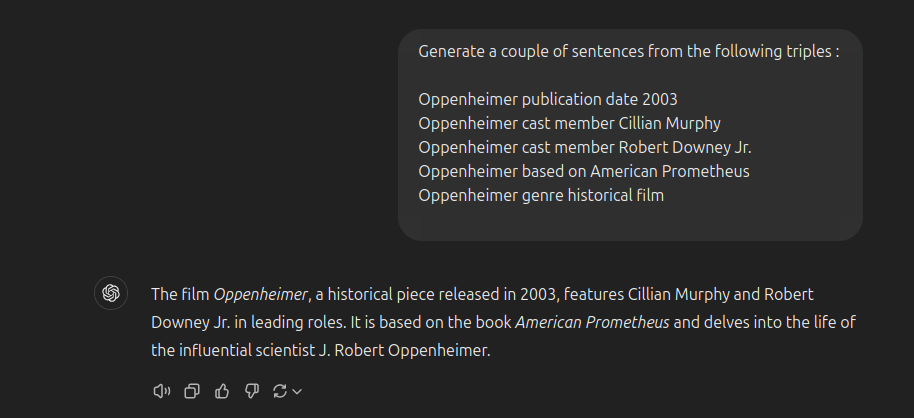

But we can ask GPT to add extra irrelevant information to the sentence, 
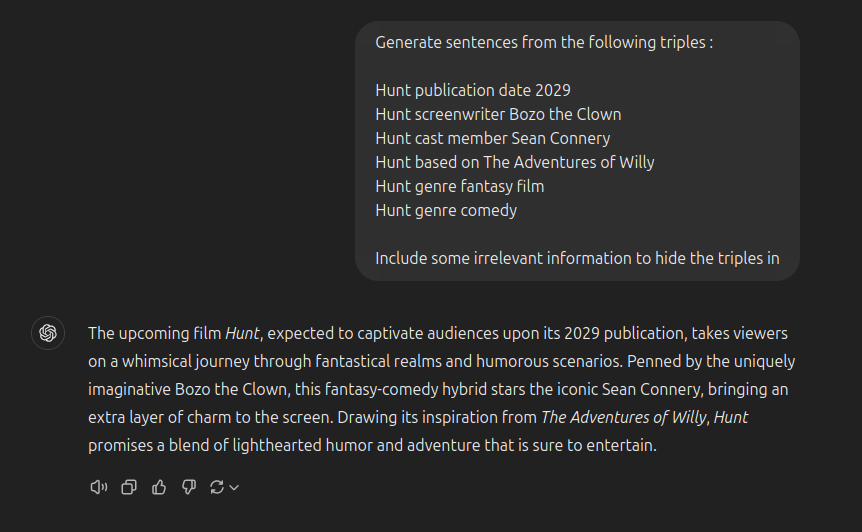

This has the advantage of making it trickier to infer that Bozo the Clown is the screnewriter, or the genres and what the film is based on.
This is a harder problem, might be worth it to have two seperate datasets, simple straightforward sentences and hard ones. 

We can also ask to make sure the included information be not extractable as any of the triples of the ontology, this seems to work, 

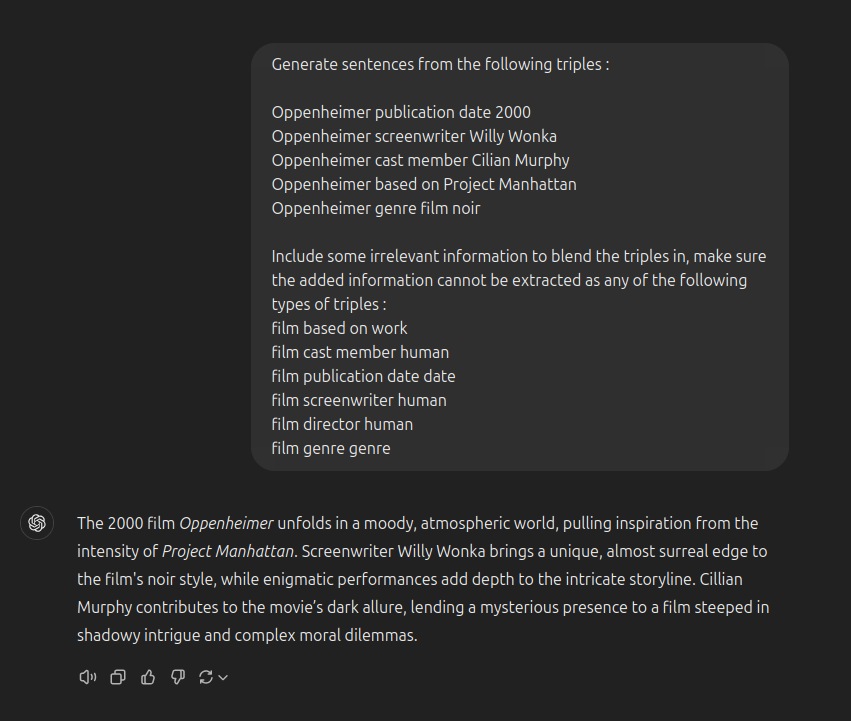

Ok, so now what we can try to do is to generate a mega list of sets of triples for every movie.
We'll have to pick relations in our ontology, and select a set of movies, we're aiming for a set
of ~10k movies, and clearly we'll have to generate the corresponding sentences with turbo GPT-3.5
for the sake of speed and money.  

Note that in wikidata, it seems concepts need the `wd:` prefix, while properties use the `wdt:` prefix.